In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url ="https://raw.githubusercontent.com/NepalStockData/Nepal_Stock_Data/main/Nepse_Data/Manufacturing_And_Processing/SHIVM.csv"
df = pd.read_csv(url)

In [3]:
df.head(5)

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,1,2026-09-17,685.00,695.00,680.10,685.50,1.36,"396,612.00","272,676,030.80"
1,2,2026-09-16,682.00,687.90,675.00,676.30,-0.69,"243,901.00","165,709,479.50"
2,3,2026-09-15,685.00,690.00,673.00,681.00,1.64,"462,655.00","315,697,044.30"
3,4,2026-09-14,663.00,675.00,663.00,670.00,1.06,"158,053.00","105,980,691.10"
4,5,2026-09-11,659.00,667.00,654.00,663.00,1.44,"104,620.00","69,234,644.80"


In [4]:
df["Ltp"] = pd.to_numeric(df["Ltp"], errors="coerce")

In [5]:
df['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1707 entries, 0 to 1706
Series name: Date
Non-Null Count  Dtype 
--------------  ----- 
1707 non-null   object
dtypes: object(1)
memory usage: 13.5+ KB


In [6]:
df = df.drop(columns=['S.N.'])

In [7]:
df.describe()

,Ltp,% Change
count,1375.000000,1707.000000
mean,582.063338,0.077586
std,109.334545,2.660707
min,305.000000,-9.980000
25%,512.450000,-1.315000
50%,579.000000,-0.280000
75%,641.490000,1.000000
max,999.000000,10.000000


In [8]:
print(len(df))

1707


In [9]:
df.head()

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,2026-09-17,685.00,695.00,680.10,685.5,1.36,"396,612.00","272,676,030.80"
1,2026-09-16,682.00,687.90,675.00,676.3,-0.69,"243,901.00","165,709,479.50"
2,2026-09-15,685.00,690.00,673.00,681.0,1.64,"462,655.00","315,697,044.30"
3,2026-09-14,663.00,675.00,663.00,670.0,1.06,"158,053.00","105,980,691.10"
4,2026-09-11,659.00,667.00,654.00,663.0,1.44,"104,620.00","69,234,644.80"


In [10]:
#vvi
df["Return"] = df["Ltp"].pct_change(fill_method=None)

In [11]:
df['Ltp'].isnull().sum()

np.int64(332)

In [12]:
df.dropna()

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover,Return
1,2026-09-16,682.00,687.90,675.00,676.3,-0.69,"243,901.00","165,709,479.50",-0.013421
2,2026-09-15,685.00,690.00,673.00,681.0,1.64,"462,655.00","315,697,044.30",0.006950
3,2026-09-14,663.00,675.00,663.00,670.0,1.06,"158,053.00","105,980,691.10",-0.016153
4,2026-09-11,659.00,667.00,654.00,663.0,1.44,"104,620.00","69,234,644.80",-0.010448
5,2026-09-10,663.00,665.00,652.10,653.6,-1.36,"99,214.00","65,476,402.30",-0.014178
...,...,...,...,...,...,...,...,...,...
1702,2019-03-28,323.00,353.00,323.00,333.0,-2.06,"78,450.00","26,284,816.00",0.024615
1703,2019-03-27,323.00,350.00,306.00,340.0,0.00,"170,472.00","55,440,896.00",0.021021
1704,2019-03-26,359.00,359.00,340.00,340.0,-9.81,500.00,"173,150.00",0.000000
1705,2019-03-25,398.00,398.00,377.00,377.0,-9.81,90.00,"34,350.00",0.108824


In [13]:
print(df['Return'])

0            NaN
1      -0.013421
2       0.006950
3      -0.016153
4      -0.010448
          ...   
1702    0.024615
1703    0.021021
1704    0.000000
1705    0.108824
1706    0.108753
Name: Return, Length: 1707, dtype: float64


In [63]:
df["Return_1d"] = df["Ltp"].pct_change(fill_method=None)

In [62]:
df["Return_5d"] = df["Ltp"].pct_change(fill_method=None)

In [61]:
df["Return_10d"] = df["Ltp"].pct_change(fill_method=None)

In [17]:
#moving average
df["MA_5"] = df["Ltp"].rolling(5).mean()
df["MA_10"] = df["Ltp"].rolling(10).mean()
df["MA_20"] = df["Ltp"].rolling(20).mean()

In [65]:
#Price relative to moving average
df["Price_MA5_ratio"] = df["Ltp"] / df["MA_5"]
df["Price_MA20_ratio"] = df["Ltp"] / df["MA_20"]

In [22]:
print(df.dtypes)

Date                 object
Open                 object
High                 object
Low                  object
Ltp                 float64
% Change            float64
Qty                  object
Turnover             object
Return              float64
1_day_return        float64
5_day_return        float64
10_day_return       float64
MA_5                float64
MA_10               float64
MA_20               float64
Price_MA5_Ratio     float64
Price_MA20_ratio    float64
dtype: object


In [25]:
num_cols = ['Open','High','Low','Ltp','% Change','Qty','Turnover','Return']

for col in num_cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

Daily  Trading Days Range

In [26]:
df["Daily_Range"] = df["High"] - df["Low"]

In [28]:
df["Range_pct"] = df['High'] - df['Low'] / df['Open']
#for measuring intraday volatility

In [29]:
df["Open_Close"]  = (df["Ltp"] - df["Open"]) / df["Open"]

In [31]:
df["Qty_change"] = df["Qty"].pct_change()#measuring volume change

In [32]:
df["Qty_change"] = df["Qty"].pct_change() #volume_change

In [33]:
df["Qty_MA5"] = df["Qty"].rolling(5).mean()

In [36]:
df["Qty_ratio"] = df["Qty"] / df["Qty_MA5"]
#capture unusual trading activity

In [40]:
df["Turnover_change"] = df["Turnover"].pct_change()#turnover change

In [38]:
df["Turnover_MA5"] = df["Turnover"].rolling(5).mean()

Adding Volatility (High volatility means market aggressive)

In [41]:
df["Volatility_5"] = df["Return"].rolling(5).std()

In [42]:
df["Volatility_20"] = df["Return"].rolling(20).std()

Creating ML Target

In [43]:
df["Tomorrow_Return"] = df["Return"].shift(-1)

In [53]:
df['Target'] = np.where(
    df['Tomorrow_Return'].isna(),
    np.nan,
    (df['Tomorrow_Return'] > 0).astype(int)
)

In [54]:
df[['Tomorrow_Return', 'Target']].tail(20)

,Tomorrow_Return,Target
1687,0.013115,1.0
1688,-0.012945,0.0
1689,0.019672,1.0
1690,-0.009646,0.0
1691,-0.006494,0.0
1692,0.006536,1.0
1693,0.006494,1.0
1694,0.061290,1.0
1695,-0.027356,0.0
1696,0.003125,1.0


In [55]:
df['Target'].isna().sum()

np.int64(334)

In [66]:
features = [
    "Return_1d",
    "Return_5d",
    "Return_10d",
    "Price_MA5_ratio",
    "Price_MA20_ratio",
    "Range_pct",
    "Open_Close",
    "Qty_change",
    "Qty_ratio",
    "Turnover_change",
    "Volatility_5",
    "Volatility_20"
]

ml_df = df[
    features + ['Target']
].dropna()

In [67]:
print("Original rows:", len(df))
print("Usable ML rows:", len(ml_df))

Original rows: 1333
Usable ML rows: 1332


In [47]:
df.isnull().sum()

Date                  0
Open                  0
High                  0
Low                   0
Ltp                 332
% Change              0
Qty                   0
Turnover              0
Return              334
1_day_return        334
5_day_return        334
10_day_return       334
MA_5                340
MA_10               350
MA_20               370
Price_MA5_Ratio     340
Price_MA20_ratio    370
Daily_Range           0
Range_pct             0
Open_Close          332
Qty_change            1
Qty_MA5               4
Qty_ratio             4
Turnover_Change       4
Turnover_MA5          4
Turnover_change       1
Volatility_5        342
Volatility_20       372
Tomorrow_Return     334
Target                0
dtype: int64

In [69]:
df[df['Ltp'].isna()][
    ['Date', 'Open', 'High', 'Low', 'Ltp', 'Qty', 'Turnover']
].head(20)

,Date,Open,High,Low,Ltp,Qty,Turnover


In [70]:
print("Rows:", len(df))
print("Missing Ltp:", df['Ltp'].isna().sum())
print("Missing %:", df['Ltp'].isna().mean() * 100)

Rows: 1333
Missing Ltp: 0
Missing %: 0.0


In [72]:
df = df.dropna()

In [73]:
X = df[features]

y = df["Target"]

Very important: time-series split

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [82]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [83]:
y_pred = model.predict(X_test)

In [84]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7116104868913857


In [85]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.76      0.53      0.63       122
         1.0       0.69      0.86      0.76       145

    accuracy                           0.71       267
   macro avg       0.73      0.70      0.70       267
weighted avg       0.72      0.71      0.70       267



In [86]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 65  57]
 [ 20 125]]


In [89]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    random_state=42
)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

In [90]:
print(
    accuracy_score(
        y_test,
        pred_rf
    )
)

0.8202247191011236


In [92]:
#feature importance
importance = pd.Series(
    model_rf.feature_importances_,
    index=features
)

importance = importance.sort_values(
    ascending=False
)
print(importance)

Open_Close          0.659640
Turnover_change     0.037862
Return_5d           0.036874
Qty_change          0.035973
Return_10d          0.035145
Volatility_5        0.034937
Return_1d           0.033306
Qty_ratio           0.030188
Volatility_20       0.027430
Range_pct           0.023384
Price_MA20_ratio    0.023083
Price_MA5_ratio     0.022179
dtype: float64


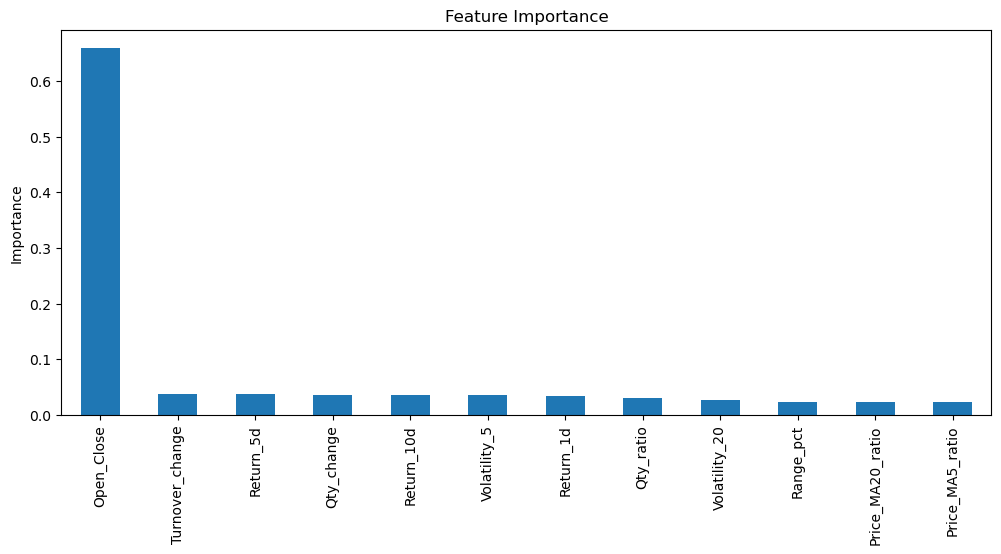

In [93]:
import matplotlib.pyplot as plt

importance.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

In [94]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [96]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(
    X_train,
    y_train
)

pred_xgb = model_xgb.predict(X_test)

Compare Models

In [97]:
results = pd.DataFrame({
    "Model": [ 
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_xgb)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.711610
1        Random Forest  0.820225
2              XGBoost  0.782772


Predict Tomorrow Price

In [98]:
df["Tomorrow_LTP"] = df["Ltp"].shift(-1)

In [99]:
y = df["Tomorrow_LTP"]

In [100]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,500
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
df["Target_Return"] = df["Ltp"].pct_change().shift(-1)

In [103]:
delta = df["Ltp"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df["RSI"] = 100-(100 / (1+rs))

Lag features are especially important

In [107]:
df["Return_lag1"] = df["Return"].shift(1)
df["Return_lag2"] = df["Return"].shift(2)
df["Return_lag3"] = df["Return"].shift(3)
df["Return_lag5"] = df["Return"].shift(5)

In [108]:
df["target"] = df["Ltp"].shift(-1)

features = [
    "Tomorrow_Return"
]

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)

In [111]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [113]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [115]:
model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

model.fit(
    X_train,
    y_train
) #pipeline are important for professional ML Models

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
